In [68]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hopesb/hr-analytics-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\uvang\.cache\kagglehub\datasets\hopesb\hr-analytics-dataset\versions\2


In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math


In [74]:
df  = pd.read_csv("hr.csv")
df

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
0,3427,20-Sep-19,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,...,1,2,3,15-Jul-23,Leadership Development,Internal,Failed,2,606.11,50
1,3428,11-Feb-23,Production Technician I,EW,Active,Contract,Zone A,Part-Time,Production,Aerial,...,2,1,5,12-Sep-22,Customer Service,External,Incomplete,4,673.02,58
2,3429,10-Dec-18,Area Sales Manager,PL,Active,Full-Time,Zone B,Part-Time,Sales,General - Sga,...,1,2,1,13-Aug-22,Leadership Development,External,Failed,2,413.28,27
3,3430,21-Jun-21,Area Sales Manager,CCDR,Active,Contract,Zone A,Full-Time,Sales,Finance & Accounting,...,5,5,4,15-Dec-22,Project Management,External,Completed,3,663.78,23
4,3431,29-Jun-19,Area Sales Manager,TNS,Active,Contract,Zone A,Temporary,Sales,General - Con,...,2,5,3,13-Jul-23,Technical Skills,External,Failed,5,399.03,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,3421,09-May-22,Production Technician I,PL,Active,Part-Time,Zone A,Part-Time,Production,Wireless,...,5,4,2,22-Jan-23,Customer Service,External,Passed,1,786.71,63
2841,3423,28-Dec-20,Production Technician I,SVG,Active,Part-Time,Zone A,Full-Time,Production,Engineers,...,4,5,3,14-Oct-22,Technical Skills,External,Completed,1,439.65,19
2842,3424,09-Dec-20,Production Technician I,TNS,Terminated,Contract,Zone B,Temporary,Production,Wireline Construction,...,2,4,5,18-Aug-22,Project Management,Internal,Completed,5,981.13,23
2843,3425,28-May-19,Production Technician I,WBL,Terminated,Contract,Zone B,Full-Time,Production,Aerial,...,5,2,3,19-May-23,Technical Skills,External,Completed,3,184.27,65


In [75]:
df = df.drop(columns=["Employee ID","StartDate", "Employee ID", "BusinessUnit", "Training Duration(Days)", "DOB",  'Training Duration(Days)', 'Training Cost',  'MaritalDesc', "Training Type"])

In [76]:
columns = list(df.columns)
columns.remove( 'Satisfaction Score')
columns.append('Satisfaction Score')

df = df[columns]

In [77]:
for i in columns[:]:    
    values = df[str(i)].unique()
    print(values)
    df[i] = df[i].replace(values, np.arange(values.size))

['Production Technician I' 'Area Sales Manager' 'Production Technician II'
 'IT Support' 'Network Engineer' 'Sr. Network Engineer'
 'Principal Data Architect' 'Enterprise Architect'
 'Database Administrator' 'Data Analyst' 'Sr. DBA' 'Data Analyst '
 'Data Architect' 'CIO' 'BI Director' 'Sr. Accountant'
 'Software Engineering Manager' 'Software Engineer'
 'Shared Services Manager' 'Senior BI Developer' 'Production Manager'
 'President & CEO' 'Administrative Assistant' 'Accountant I'
 'BI Developer' 'Sales Manager' 'IT Manager - Support'
 'IT Manager - Infra' 'IT Manager - DB' 'Director of Sales'
 'Director of Operations' 'IT Director']
['Active' 'Terminated']
['Contract' 'Full-Time' 'Part-Time']
['Zone C' 'Zone A' 'Zone B']
['Temporary' 'Part-Time' 'Full-Time']
['Production       ' 'Sales' 'IT/IS' 'Executive Office'
 'Software Engineering' 'Admin Offices']
['Finance & Accounting' 'Aerial' 'General - Sga' 'General - Con'
 'Field Operations' 'General - Eng' 'Engineers' 'Executive' 'Splici

C:\Users\uvang\AppData\Local\Temp\ipykernel_11496\3488618538.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[i] = df[i].replace(values, np.arange(values.size))


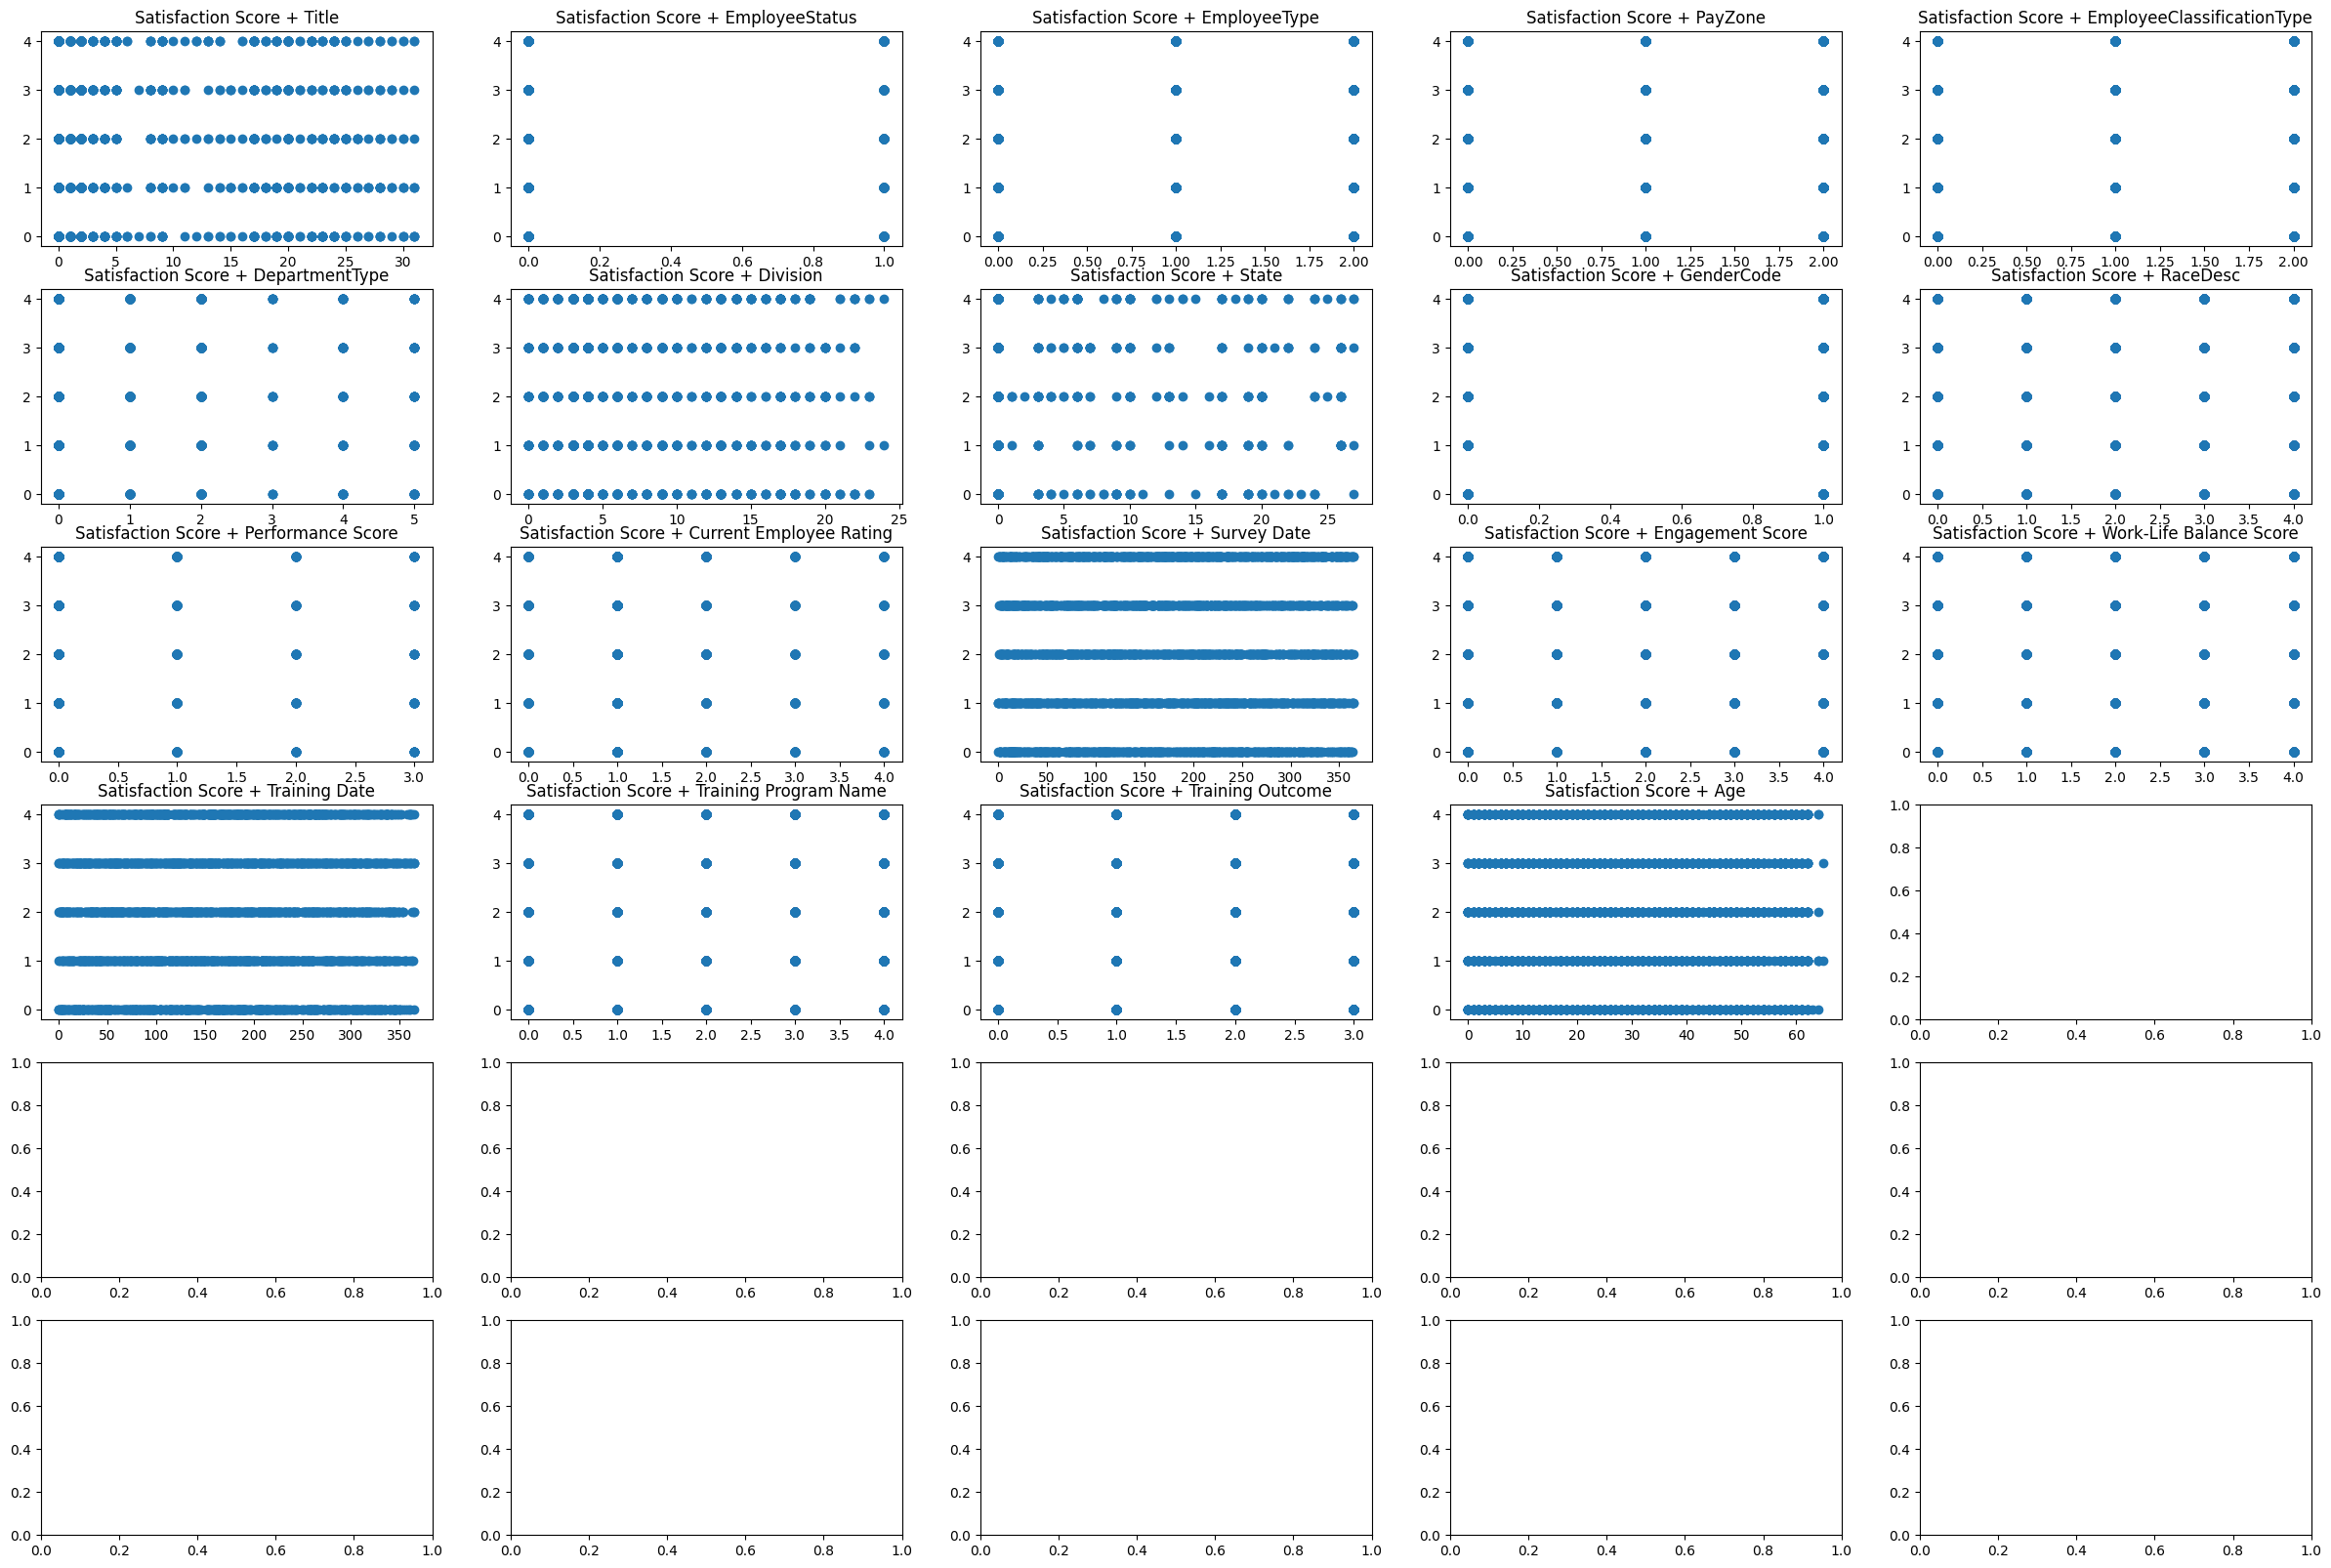

In [ ]:
def plot_data(X,y ,ax, pos_label="y=1" ,neg_label = "y=0", s=80, loc ="best"):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr")

def plot_data_y(X,y ,ax):
    ax.scatter(X, y)

column_names = list(df.columns.values)
column_names = column_names[:-1]
column_l = column_names.__len__()

fig,ax = plt.subplots(6,5,figsize=(30,20))
i,k = 0,0
num = 0
y_train = np.array(df["Satisfaction Score"])
y_train =y_train.reshape(-1, 1)

while(num < column_l):
    x_train = np.array(df[column_names[num]])
    plot_data_y(x_train, y_train, ax[k][i])
    ax[k][i].set_title(rf"Satisfaction Score + {column_names[num]}")
    if i == 4:
        i = 0
        k +=1
    else:
        i+=1
    num+=1


plt.show()


In [ ]:
temp = np.unique(y_train)
len(temp)

5

In [ ]:
column_names = list(df.columns.values)
column_names = column_names[:-1]
column_l = column_names.__len__()
fig,ax = plt.subplots(int(column_l * math.log(column_l)) - 10 ,5,figsize=(60,200))
i,k = 0,0
num = 0
while(num < int(column_l * math.log(column_l))):
    for j in range(num +1, column_l):
        x_train = np.array([df[column_names[num]],df[column_names[j]]])
        x_train = np.column_stack((x_train[0], x_train[1]))
        plot_data(x_train, y_train, ax[i][k])
        ax[i][k].set_title(rf"{column_names[num]}  {column_names[j]}")
        if k == 4:
            k = 0
            i+=1
        else:
            k += 1
    num +=1


In [149]:
def plot_data(X,y ,ax, pos_label="y=1" ,neg_label = "y=0", s=80, loc ="best"):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", label=y)
    unique_classes = np.unique(y)
    colors = ['blue', 'red']  # Define colors for each class
    labels = [f'Class {cls}' for cls in unique_classes]  # Define labels

    

mask = (y_train == 0) | (y_train == 4)
y_train = y_train.ravel()  # Converts shape from (2845, 1) -> (2845,)
mask = mask.ravel()
y_filtered = y_train[mask]
fig,ax = plt.subplots(int(column_l * math.log(column_l)) - 10 ,5,figsize=(60,200))
i,k = 0,0
num = 0


while(num < int(column_l * math.log(column_l))):
    for j in range(num +1, column_l):
        x_train = np.array([df[column_names[num]],df[column_names[j]]])
        x_train = np.column_stack((x_train[0], x_train[1]))
        x_filtered = x_train[mask]
        plot_data(x_filtered, y_filtered, ax[i][k])
        ax[i][k].set_title(rf"{column_names[num]}  {column_names[j]}")
        if k == 4:
            k = 0
            i+=1
        else:
            k += 1
    num +=1
plt.legend()
plt.show()


C:\Users\uvang\AppData\Local\Temp\ipykernel_11496\1195717268.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


In [136]:
print(mask)

[[ True]
 [False]
 [ True]
 ...
 [ True]
 [ True]
 [False]]


In [137]:
print("x_train shape:", x_train.shape)  # Should be (N, 2)
print("y_train shape:", y_train.shape)  # Should be (N,)
print("mask shape:", mask.shape)  # Should be (N,)


x_train shape: (2845, 2)
y_train shape: (2845, 1)
mask shape: (2845, 1)


In [128]:
np.unique(y_filtered)

masked_array(data=[1, 2, 3, --],
             mask=[False, False, False,  True],
       fill_value=999999)